---

<a id="section1"></a>
# <font color="#004D7F"> 1. Introducción</font>

<a id="section11"></a>
## <font color="#004D7F"> 1.1. Importar librerías</font>

In [141]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import pickle
from imblearn.combine import SMOTETomek
from collections import Counter
from imblearn.under_sampling import NearMiss
from sklearn.preprocessing import MinMaxScaler

<a id="section12"></a>
## <font color="#004D7F"> 1.2. Cargar dataset</font>

In [142]:
filename = "classificador final clemesi.xlsx"
#dataset = pd.read_csv(filename)
dataset = pd.read_excel(filename)

In [143]:
dataset.dtypes

Power (KW)             float64
irradiance corr PYR    float64
Classification          object
dtype: object

In [144]:
#Variables a considerar
#dataset = dataset[["Power (KW)","irradiance corr PYR","clearsky_index","Macro_Cause_INV"]]

<a id="section2"></a>
# <font color="#004D7F"> 2. Estadística descriptiva</font>

<a id="section21"></a>
## <font color="#004D7F"> 2.1. Dimensiones del conjunto de datos</font>

In [145]:
dataset.shape

(8959, 3)

<a id="section22"></a>
## <font color="#004D7F"> 2.2. Visualización de datos</font>

In [146]:
dataset.head()

,Power (KW),irradiance corr PYR,Classification
0,2856.0,1250.0,Inverter Overtemperature / Wrong regulation se...
1,2837.0,1205.0,Inverter Overtemperature / Wrong regulation se...
2,2436.0,1221.0,Inverter Overtemperature / Wrong regulation se...
3,2462.0,1129.0,Inverter Overtemperature / Wrong regulation se...
4,2946.0,1220.0,Inverter Overtemperature / Wrong regulation se...


<a id="section23"></a>
## <font color="#004D7F"> 2.3. Resumen estadístico</font>

In [147]:
dataset.describe()

,Power (KW),irradiance corr PYR
count,8959.000000,8959.000000
mean,1782.002305,855.945351
std,838.578297,357.530984
min,5.000000,61.000000
25%,1212.050000,599.100000
50%,1887.000000,939.000000
75%,2516.000000,1145.000000
max,3070.000000,1500.000000


<a id="section24"></a>
## <font color="#004D7F"> 2.4. Distribución de clase</font>

In [148]:
dataset["Classification"].unique()

array(['Inverter Overtemperature / Wrong regulation setting',
       'Grid limitation / Market regulation',
       'Tracking system failure or inefficiency', 'Fuses melt', 'Clouds'],
      dtype=object)

In [149]:
# class distribution
dataset.groupby('Classification').size()

Classification
Clouds                                                 4718
Fuses melt                                              674
Grid limitation / Market regulation                    1378
Inverter Overtemperature / Wrong regulation setting    1379
Tracking system failure or inefficiency                 810
dtype: int64

In [150]:
# #Agrupando clases
# filter1 = dataset['Macro_Cause_INV'].str.contains('Electronic Board Fan Unavailability|IGBT Fan Unavailability|Inverter Overtemperature',case=False)
# dataset.loc[filter1,"Macro_Cause_INV"] = 'Electronic Board, temperature'

# filter2 = dataset['Macro_Cause_INV'].str.contains('Dirty Pyranometer|Soiling effect',case=False)
# dataset.loc[filter2,"Macro_Cause_INV"] = 'Soiling'

# filter3 = dataset['Macro_Cause_INV'].str.contains('Grid Curtailment|Grid Limitation',case=False)
# dataset.loc[filter3,"Macro_Cause_INV"] = 'Grid Limitation'

# filter4 = dataset['Macro_Cause_INV'].str.contains('S-effect|Shadow-leaf Effect|Shadowing Effect',case=False)
# dataset.loc[filter4,"Macro_Cause_INV"] = 'Shadowing Effect'

# filter5 = dataset['Macro_Cause_INV'].str.contains('S-effect|Shadow-leaf Effect|Shadowing Effect',case=False)
# dataset.loc[filter4,"Macro_Cause_INV"] = 'Shadowing Effect'

# #Eliminando algunas clases
# delete1 = dataset['Macro_Cause_INV'].str.contains('Outage|TO_Check|Not Class Ineff|Communication issues|Tracker Unavailability',case=False)
# dataset = dataset.loc[~delete1].copy()

# delete2 = dataset['Macro_Cause_INV'].str.contains('Electronic Board, temperature|Forced|Ice or Snow on PV Panels|Inefficiency',case=False)
# dataset = dataset.loc[~delete2].copy()

# delete3 = dataset['Macro_Cause_INV'].str.contains('Modular Inverter Fault|Planned|Ice or Snow on PV Panels|Strings not in Operation',case=False)
# dataset = dataset.loc[~delete3].copy()

# dataset.groupby('Macro_Cause_INV').size()

<a id="section3"></a>
# <font color="#004D7F"> 3. Visualización del conjunto de datos</font>

In [151]:
carpeta_guardado = "./INV_complete_images/"

<a id="section31"></a>
## <font color="#004D7F"> 3.1. Gráficos Univariados</font>

<a id="section311"></a>
### <font color="#004D7F"> Boxplots</font>
Dado que las variables de entrada son numéricas, podemos crear Gráficas Boxplots de cada uno

C:\Users\Jteso\AppData\Local\Temp\ipykernel_15504\2620247017.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  dataset.plot(ax=ax, kind='box', subplots=True, layout=(1,3), sharex=False, sharey=False)


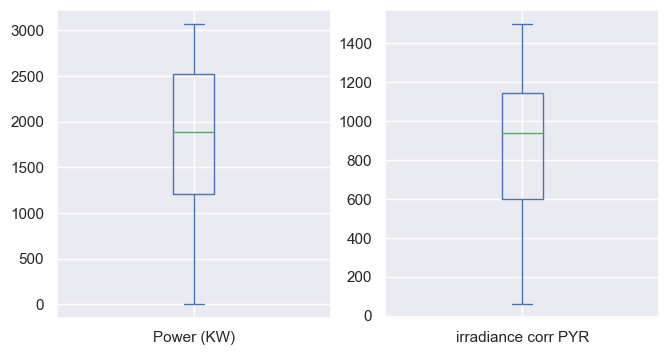

In [152]:
# DIAGRAMA DE BIGOTES DE TODO SOLAR

fig = plt.figure(figsize = (12,4))
ax = fig.gca()
dataset.plot(ax=ax, kind='box', subplots=True, layout=(1,3), sharex=False, sharey=False)

plt.savefig(carpeta_guardado + "todos_boxplot.jpeg")
            
plt.show()

C:\Users\Jteso\AppData\Local\Temp\ipykernel_15504\419984780.py:8: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  dataset.loc[dataset["Classification"] == i].plot(ax=ax, kind='box', subplots=True, layout=(1,3), sharex=False, sharey=False)


Inverter Overtemperature / Wrong regulation setting


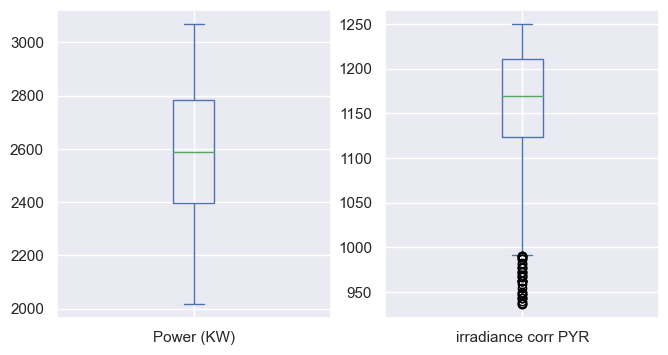

Grid limitation / Market regulation


C:\Users\Jteso\AppData\Local\Temp\ipykernel_15504\419984780.py:8: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  dataset.loc[dataset["Classification"] == i].plot(ax=ax, kind='box', subplots=True, layout=(1,3), sharex=False, sharey=False)


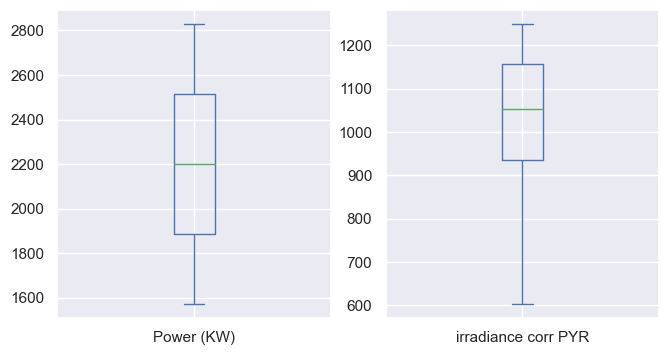

Tracking system failure or inefficiency


C:\Users\Jteso\AppData\Local\Temp\ipykernel_15504\419984780.py:8: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  dataset.loc[dataset["Classification"] == i].plot(ax=ax, kind='box', subplots=True, layout=(1,3), sharex=False, sharey=False)


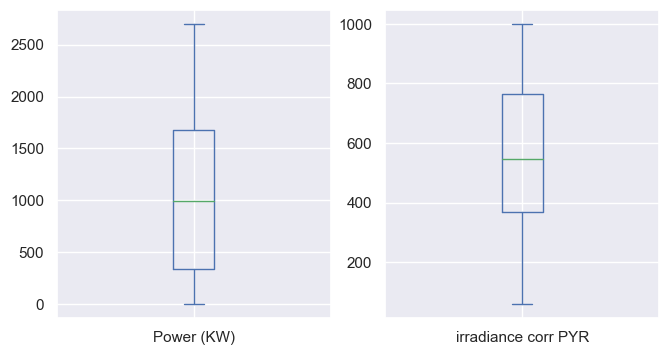

C:\Users\Jteso\AppData\Local\Temp\ipykernel_15504\419984780.py:8: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  dataset.loc[dataset["Classification"] == i].plot(ax=ax, kind='box', subplots=True, layout=(1,3), sharex=False, sharey=False)


Fuses melt


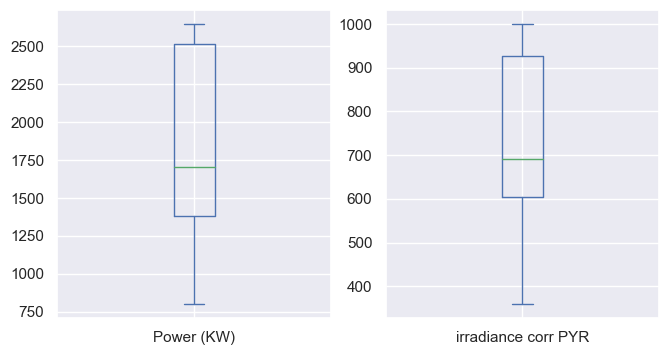

C:\Users\Jteso\AppData\Local\Temp\ipykernel_15504\419984780.py:8: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  dataset.loc[dataset["Classification"] == i].plot(ax=ax, kind='box', subplots=True, layout=(1,3), sharex=False, sharey=False)


Clouds


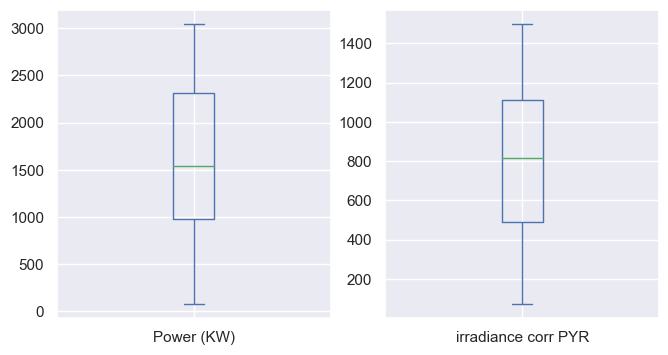

In [153]:
#DIAGRAMA BIGOTES DE SOLAR POR ESTADO

for i in ['Inverter Overtemperature / Wrong regulation setting',
       'Grid limitation / Market regulation',
       'Tracking system failure or inefficiency', 'Fuses melt', 'Clouds']:
    fig = plt.figure(figsize = (12,4))
    ax = fig.gca()
    dataset.loc[dataset["Classification"] == i].plot(ax=ax, kind='box', subplots=True, layout=(1,3), sharex=False, sharey=False)
    print(i)
    plt.savefig(carpeta_guardado + i.replace('/',"_") +"_boxplot.jpeg")
    plt.show()

<a id="section312"></a>
### <font color="#004D7F"> Histograma</font>

In [154]:
dataset.columns[:-1]

Index(['Power (KW)', 'irradiance corr PYR'], dtype='object')

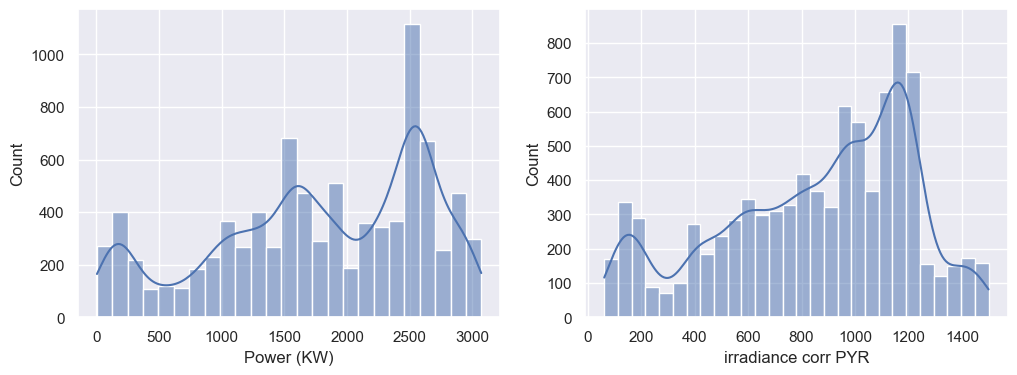

In [155]:
# histograms - Seaborn

sns.set(style="darkgrid")

filas = 1
cols = 2
nombre_cols = dataset.columns[:-1]
cont = 0

fig, axs = plt.subplots(filas, cols, figsize=(12, 4))


for k in range(cols):
    sns.histplot(data=dataset[nombre_cols[cont]], ax=axs[k],kde=True)
    cont+=1

<a id="section32"></a>
## <font color="#004D7F"> 3.2. Gráficos multivariados</font>

<a id="section321"></a>
### <font color="#004D7F"> Diagramas de dispersión</font>

C:\Users\Jteso\anaconda3\envs\Analisis\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Jteso\anaconda3\envs\Analisis\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Jteso\anaconda3\envs\Analisis\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Jteso\anaconda3\envs\Analisis\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Jteso\anaconda3\envs\Analisis\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


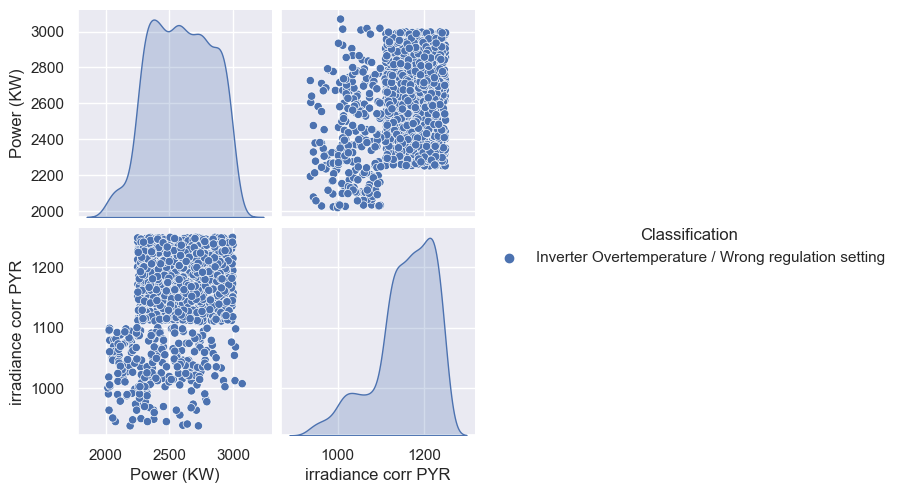

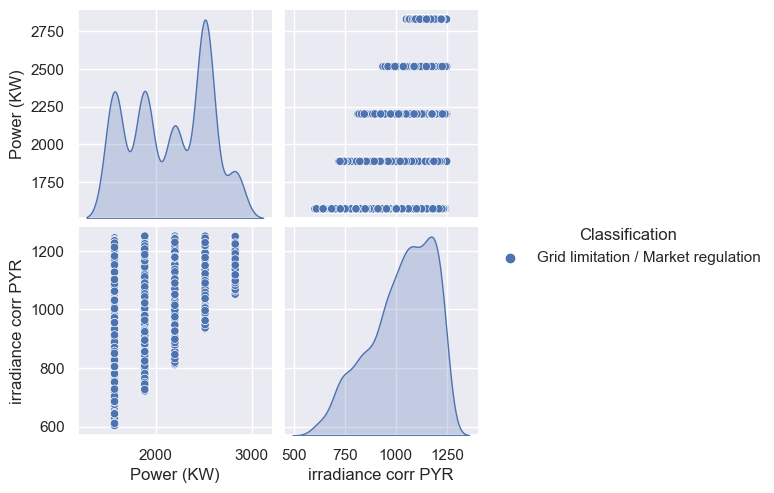

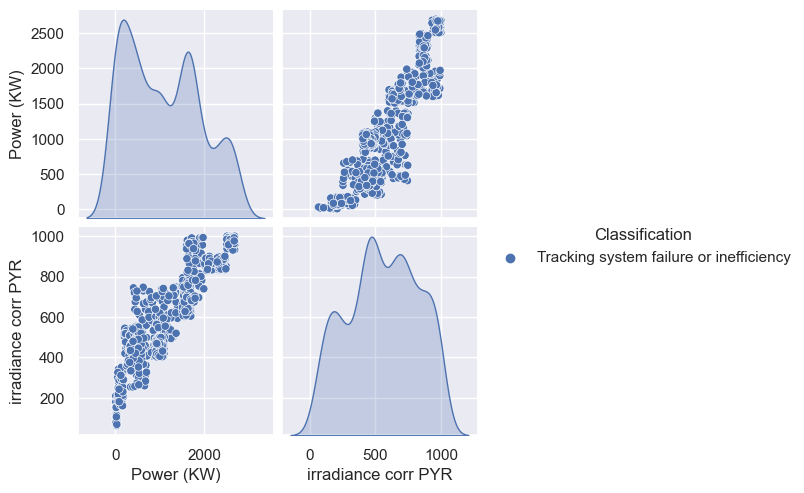

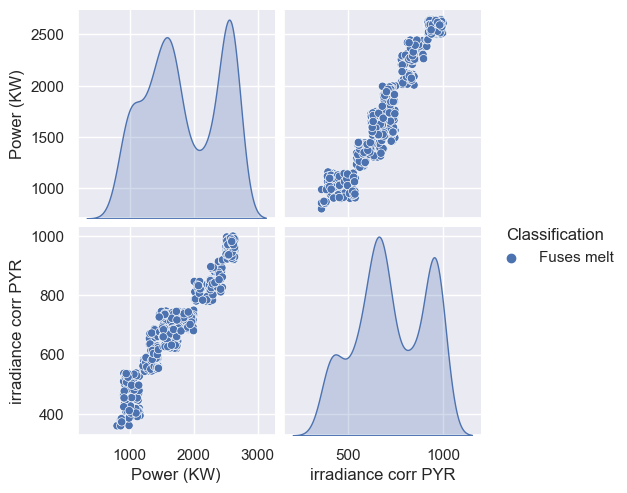

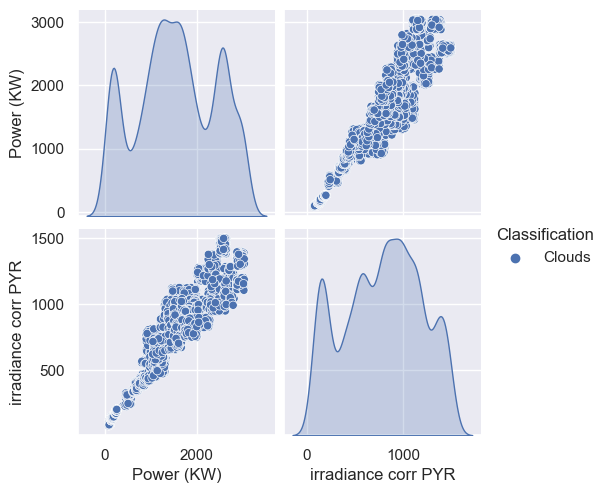

In [156]:
for i in dataset["Classification"].unique():
    sns.pairplot(dataset.loc[dataset["Classification"]==i], hue="Classification");

C:\Users\Jteso\anaconda3\envs\Analisis\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


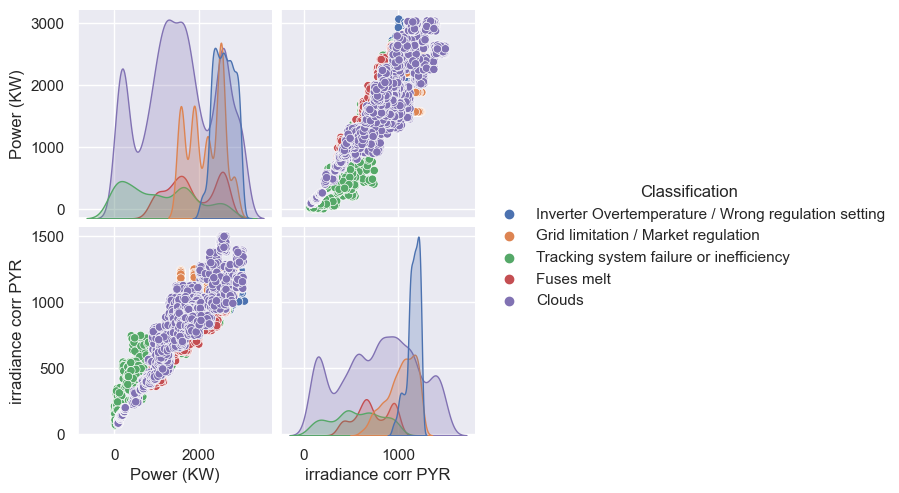

In [157]:
sns.pairplot(dataset, hue="Classification");

<a id="section322"></a>
### <font color="#004D7F"> Diagramas de correlación Pearson</font>

C:\Users\Jteso\AppData\Local\Temp\ipykernel_15504\2968242813.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(dataset.corr(), vmin=-1, vmax=1)


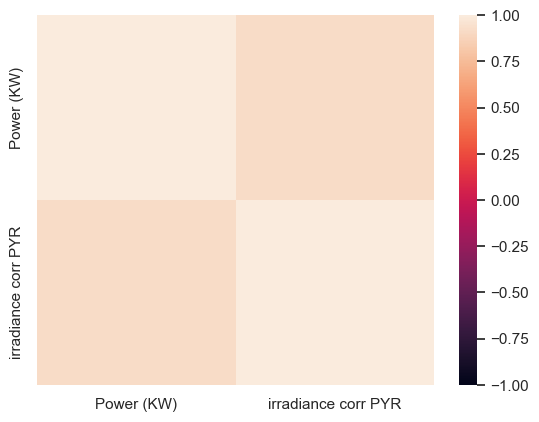

In [158]:
sns.heatmap(dataset.corr(), vmin=-1, vmax=1)

plt.savefig(carpeta_guardado + "todos_heatmap.jpeg")

<a id="section4"></a>
# <font color="#004D7F"> 4. Tratamiento de datos</font>

<a id="section41"></a>
## <font color="#004D7F"> 4.1. Datos vacios</font>

In [159]:
#ELIMINAMOS DATOS QUE NO TIENEN CLASIFICACION
categorical_col = "Classification"
dataset = dataset.loc[~dataset[categorical_col].isnull()].copy()
dataset["Classification"].unique()

array(['Inverter Overtemperature / Wrong regulation setting',
       'Grid limitation / Market regulation',
       'Tracking system failure or inefficiency', 'Fuses melt', 'Clouds'],
      dtype=object)

In [160]:
dataset["Classification"].value_counts()

Clouds                                                 4718
Inverter Overtemperature / Wrong regulation setting    1379
Grid limitation / Market regulation                    1378
Tracking system failure or inefficiency                 810
Fuses melt                                              674
Name: Classification, dtype: int64

In [161]:
dataset.shape 

(8959, 3)

In [162]:
#SE AGREGA DATOS VACIOS CON MEDIANA O MODA (NUMERICO O NO NUMERICO)
variables = dataset.iloc[:,0:-1].reset_index(drop=True)
clase = dataset.iloc[:,-1:].reset_index(drop=True)

imp = SimpleImputer(strategy = 'median')
imp.fit(variables)
variables_t = imp.transform(variables)
variables_t = pd.DataFrame(variables_t, columns=variables.columns)
dataset = pd.concat([variables_t,clase],axis=1)

dataset.head()

,Power (KW),irradiance corr PYR,Classification
0,2856.0,1250.0,Inverter Overtemperature / Wrong regulation se...
1,2837.0,1205.0,Inverter Overtemperature / Wrong regulation se...
2,2436.0,1221.0,Inverter Overtemperature / Wrong regulation se...
3,2462.0,1129.0,Inverter Overtemperature / Wrong regulation se...
4,2946.0,1220.0,Inverter Overtemperature / Wrong regulation se...


In [163]:
#VERIFICAR SI HAY DATOS VACIOS
dataset.isnull().any().any()

False

<a id="section42"></a>
## <font color="#004D7F"> 4.2. Datos fuera de rango</font>

In [164]:
# #Nitrogeno > 100 000
# dataset = dataset.loc[~(dataset["nitrogen"]>100000)].copy()

# #Acetileno > 12000
# dataset = dataset.loc[~(dataset["acetylene"]>12000)].copy()

# #Etano > 6000
# dataset = dataset.loc[~(dataset["ethane"]>6000)].copy()

# #Etileno > 15000
# dataset = dataset.loc[~(dataset["ethylene"]>15000)].copy()

# dataset = dataset.reset_index(drop=True).copy()

In [165]:
# box and whisker plots - Matplotlib
# fig = plt.figure(figsize = (12,12))
# ax = fig.gca()
# dataset.plot(ax=ax, kind='box', subplots=True, layout=(4,3), sharex=False, sharey=False)
# plt.show()

<a id="section43"></a>
## <font color="#004D7F"> 4.3. Datos sin distibución gaussiana</font>

In [166]:
BU = dataset.copy()

In [167]:
#Se aplica yeo-johnson para conseguir una distribucion gaussiana

variables = dataset.iloc[:,0:-1].reset_index(drop=True)
clase = dataset.iloc[:,-1].reset_index(drop=True)

pt = PowerTransformer(method='yeo-johnson',standardize=True)
skl_boxcox = pt.fit(variables)
cal_lambdas = skl_boxcox.lambdas_
skl_boxcox = pt.transform(variables)

variables = pd.DataFrame(data=skl_boxcox, columns=variables.columns)
dataset = pd.concat([variables,clase],axis=1).copy()
dataset.head()

,Power (KW),irradiance corr PYR,Classification
0,1.297966,1.148316,Inverter Overtemperature / Wrong regulation se...
1,1.274525,1.005403,Inverter Overtemperature / Wrong regulation se...
2,0.781590,1.056076,Inverter Overtemperature / Wrong regulation se...
3,0.813441,0.766881,Inverter Overtemperature / Wrong regulation se...
4,1.409103,1.052904,Inverter Overtemperature / Wrong regulation se...


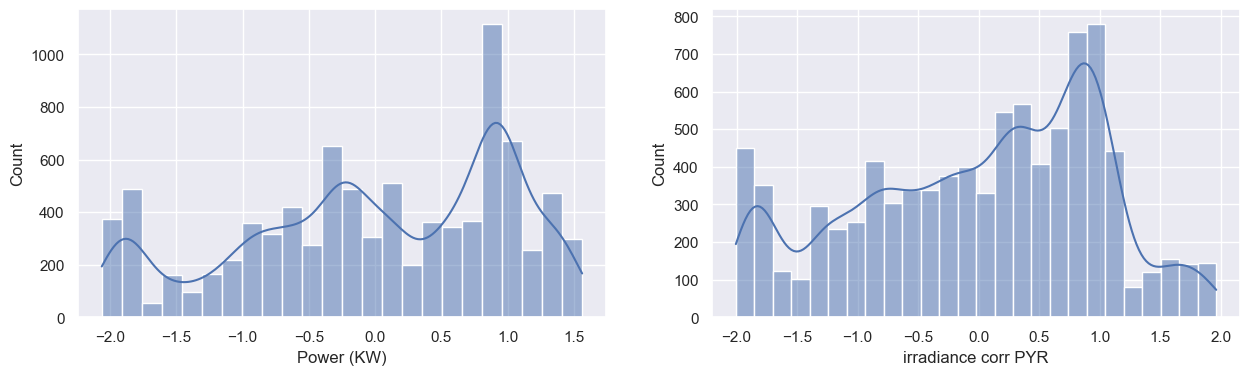

In [168]:
#HISTOGRAMA CON DISTRIBUCION GAUSSIANA

sns.set(style="darkgrid")

filas = 1
cols = 2
nombre_cols = dataset.columns[:-1]
cont = 0

fig, axs = plt.subplots(filas, cols, figsize=(15, 4))


for k in range(cols):
    sns.histplot(data=dataset[nombre_cols[cont]], ax=axs[k],kde=True)
    cont+=1

<a id="section44"></a>
## <font color="#004D7F"> 4.4. Selección de variables de entrada relevantes</font>

In [169]:
#IMPORTANCIAS DE CARACTERISTICAS POR RANDOMFOREST

X = dataset.iloc[:,0:-1]
y = dataset.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

forest = RandomForestClassifier(n_estimators=100)
forest.fit(X_train,y_train)
importances = forest.feature_importances_
y_pred = forest.predict(X_test)

ranking = np.argsort(forest.feature_importances_)
print(dataset.columns[ranking])

Index(['irradiance corr PYR', 'Power (KW)'], dtype='object')


In [170]:
ranking

array([1, 0], dtype=int64)

<a id="section5"></a>
# <font color="#004D7F"> 5. Fase de modelado</font>

In [171]:
dataset["Classification"].value_counts()

Clouds                                                 4718
Inverter Overtemperature / Wrong regulation setting    1379
Grid limitation / Market regulation                    1378
Tracking system failure or inefficiency                 810
Fuses melt                                              674
Name: Classification, dtype: int64

<a id="section51"></a>
## <font color="#004D7F"> 5.1. Crear conjunto de validación</font>

In [172]:
array = dataset.values
X = dataset.iloc[:,0:-1]
y = dataset.iloc[:,-1]
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=validation_size, random_state=seed)

<a id="section52"></a>
## <font color="#004D7F"> 5.2. Crear conjunto de validación balanceado</font>

In [173]:
BU["Classification"].value_counts()

Clouds                                                 4718
Inverter Overtemperature / Wrong regulation setting    1379
Grid limitation / Market regulation                    1378
Tracking system failure or inefficiency                 810
Fuses melt                                              674
Name: Classification, dtype: int64

In [174]:
sub_dataset = BU.copy()
df_submuestreado = sub_dataset[sub_dataset['Classification'] != "Clouds"]
df_submuestreado = df_submuestreado.append(sub_dataset[sub_dataset['Classification'] == "Clouds"].sample(frac=0.55, random_state=42))

C:\Users\Jteso\AppData\Local\Temp\ipykernel_15504\244409162.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_submuestreado = df_submuestreado.append(sub_dataset[sub_dataset['Classification'] == "Clouds"].sample(frac=0.55, random_state=42))


In [175]:
df_submuestreado["Classification"].value_counts()

Clouds                                                 2595
Inverter Overtemperature / Wrong regulation setting    1379
Grid limitation / Market regulation                    1378
Tracking system failure or inefficiency                 810
Fuses melt                                              674
Name: Classification, dtype: int64

In [176]:
array = dataset.values
X = df_submuestreado.iloc[:,0:-1]
y = df_submuestreado.iloc[:,-1]
validation_size = 0.25
seed = 7

In [177]:
# dict_class = {'NO LOSSES': 10000,
#              'Clouds': 9000}

#SMOKETomek

os_us = SMOTETomek(sampling_strategy='auto',random_state=42)

X_res, y_res = os_us.fit_resample(X, y)

print ("Distribution before resampling {}".format(Counter(y)))
print ("Distribution after resampling {}".format(Counter(y_res)))

X = X_res.copy()
y = y_res.copy()

X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=validation_size, random_state=seed)

Distribution before resampling Counter({'Clouds': 2595, 'Inverter Overtemperature / Wrong regulation setting': 1379, 'Grid limitation / Market regulation': 1378, 'Tracking system failure or inefficiency': 810, 'Fuses melt': 674})
Distribution after resampling Counter({'Grid limitation / Market regulation': 2578, 'Inverter Overtemperature / Wrong regulation setting': 2491, 'Fuses melt': 2469, 'Tracking system failure or inefficiency': 2393, 'Clouds': 2336})


C:\Users\Jteso\anaconda3\envs\Analisis\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


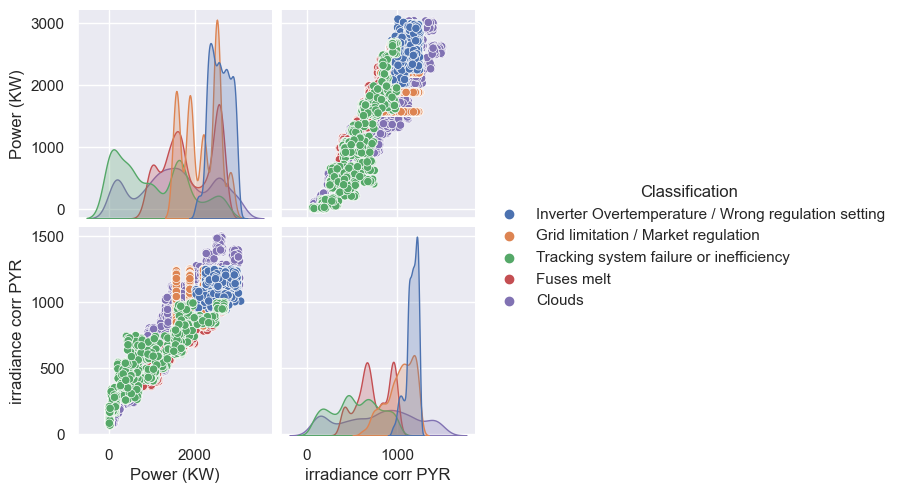

In [178]:
dataset_modified = pd.DataFrame(columns = dataset.columns)

dataset_modified[dataset.columns[-1]] = y
dataset_modified[dataset.columns[:-1]] = X

sns.pairplot(dataset_modified, hue="Classification");

# sns.pairplot(dataset_modified.loc[
#                          (dataset_modified["Macro_Cause_INV"]=="NO LOSSES")
#                         ], hue="Macro_Cause_INV");

<a id="section53"></a>
## <font color="#004D7F"> 5.3. Validación cruzada</font>

Utilizaremos la validación cruzada 10 veces para estimar el Accuracy. Esto dividirá nuestro conjunto de datos en 10 partes, entrenará en 9 y probará en 1 y repetirá para todas las combinaciones de divisiones de train/test. Estamos utilizando la métrica de Accuracy para evaluar modelos. Esta es una proporción del número de instancias correctamente predichas dividido por el número total de instancias en el conjunto de datos multiplicado por 100 para dar un porcentaje (por ejemplo, 95% de Accuracy).

<a id="section54"></a>
## <font color="#004D7F"> 5.4. Evaluar modelos</font>

In [179]:
# Spot-Check Algorithms
models = []
models.append(('LoR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('k-NN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))
models.append(('RF', RandomForestClassifier()))
#models.append(('XGB', xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)))
# evaluate each model in turn
results = []
names = []
seed=3
for name, model in models:
    
    #PIPELINE
    estimators = []
    estimators.append(('standardize',StandardScaler()))
    estimators.append(('yeo_johnson', PowerTransformer(method='yeo-johnson',standardize=True)))
    estimators.append((name,model))
    model_PIPELINE = Pipeline(estimators)

    kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model_PIPELINE, X_train, Y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean()*100.0:,.2f}% ({cv_results.std()*100.0:,.2f}%)")

LoR: 49.24% (2.12%)
LDA: 48.58% (1.69%)
k-NN: 87.50% (0.96%)
CART: 91.07% (0.94%)
NB: 50.20% (2.24%)
SVM: 64.37% (1.75%)
RF: 92.23% (0.58%)


<a id="section55"></a>
## <font color="#004D7F"> 5.5. Seleccionar modelos</font>

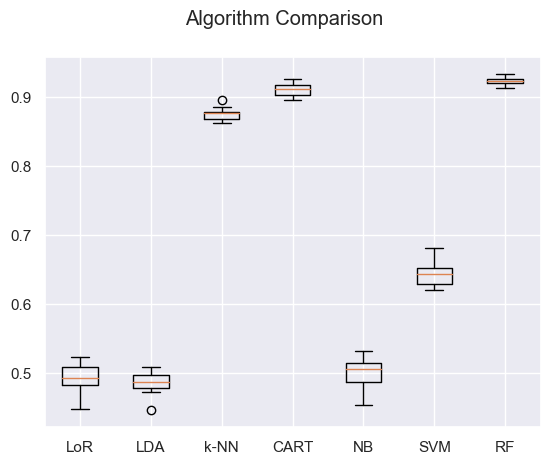

In [180]:
# Compare Algorithms
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)

plt.savefig(carpeta_guardado + "comparacion_modelos.jpeg")

plt.show()

<a id="section6"></a>
# <font color="#004D7F"> 6. Fase de Forecasting</font>

<a id="section61"></a>
## <font color="#004D7F"> 6.1. Seleccionar de hiperparametros</font>

<a id="section611"></a>
### <font color="#004D7F"> KNN</font>

In [181]:
# SE SELECCIONA RANDOMFOREST POR MEJOR PRECISION

#PIPELINE
estimators = []
estimators.append(('standardize',StandardScaler()))
estimators.append(('yeo_johnson', PowerTransformer(method='yeo-johnson',standardize=True)))
estimators.append(("classifier",KNeighborsClassifier()))
model_PIPELINE = Pipeline(estimators)
    
model_PIPELINE.fit(X_train, Y_train)
predictions = model_PIPELINE.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.8747962178024128
[[452  26  41  48  46]
 [  6 540   7   0  36]
 [  1   5 642   0   0]
 [ 15   1  31 560   3]
 [ 33  72  13   0 489]]
                                                     precision    recall  f1-score   support

                                             Clouds       0.89      0.74      0.81       613
                                         Fuses melt       0.84      0.92      0.88       589
                Grid limitation / Market regulation       0.87      0.99      0.93       648
Inverter Overtemperature / Wrong regulation setting       0.92      0.92      0.92       610
            Tracking system failure or inefficiency       0.85      0.81      0.83       607

                                           accuracy                           0.87      3067
                                          macro avg       0.88      0.87      0.87      3067
                                       weighted avg       0.88      0.87      0.87      3067



In [182]:
#GRIDSEARCH (SE SELECCIONA LOS MEJORES HIPERPARAMETROS)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('yeo_johnson', PowerTransformer(method='yeo-johnson',standardize=True)),
    #('pca', PCA(n_components=4)),
    ('classifier', KNeighborsClassifier())
])

param_grid = {
    'scaler__with_mean': [True, False],
    'classifier__n_neighbors':[3,5,7,9],
    'classifier__algorithm': ["auto", "ball_tree", "kd_tree", "brute"],
}

grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)
print("Mejores parámetros:", grid_search.best_params_)
accuracy = grid_search.best_estimator_.score(X_validation, Y_validation)
print("Precisión en el conjunto de prueba:", accuracy)

Mejores parámetros: {'classifier__algorithm': 'auto', 'classifier__n_neighbors': 3, 'scaler__with_mean': False}
Precisión en el conjunto de prueba: 0.8881643299641343


<a id="section612"></a>
### <font color="#004D7F"> RF</font>

In [55]:
# SE SELECCIONA RANDOMFOREST POR MEJOR PRECISION

#PIPELINE
estimators = []
estimators.append(('standardize',StandardScaler()))
estimators.append(("Classifier",RandomForestClassifier()))
model_PIPELINE = Pipeline(estimators)
    
model_PIPELINE.fit(X_train, Y_train)
predictions = model_PIPELINE.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.9234579018460153
[[357  14   2  34  15]
 [  2 423   3   0  17]
 [  0   0 465   0   0]
 [  6   1   2 438   1]
 [ 30  43   0   0 368]]
                                                     precision    recall  f1-score   support

                                             Clouds       0.90      0.85      0.87       422
                                         Fuses melt       0.88      0.95      0.91       445
                Grid limitation / Market regulation       0.99      1.00      0.99       465
Inverter Overtemperature / Wrong regulation setting       0.93      0.98      0.95       448
            Tracking system failure or inefficiency       0.92      0.83      0.87       441

                                           accuracy                           0.92      2221
                                          macro avg       0.92      0.92      0.92      2221
                                       weighted avg       0.92      0.92      0.92      2221



In [92]:
#GRIDSEARCH (SE SELECCIONA LOS MEJORES HIPERPARAMETROS)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier())
])

param_grid = {
    'scaler__with_mean': [True, False],
    'classifier__n_estimators': [10, 50, 100],
    'classifier__max_depth': [None, 10, 20, 50],
    #'classifier__min_samples_split': [2, 5, 10],
    #'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)
print("Mejores parámetros:", grid_search.best_params_)
accuracy = grid_search.best_estimator_.score(X_validation, Y_validation)
print("Precisión en el conjunto de prueba:", accuracy)

Mejores parámetros: {'classifier__max_depth': 50, 'classifier__n_estimators': 100, 'scaler__with_mean': False}
Precisión en el conjunto de prueba: 0.912292142158461


<a id="section62"></a>
## <font color="#004D7F"> 6.2. Guardado de modelo</font>

In [183]:
#KNN

estimators = []
estimators.append(('yeo_johnson', PowerTransformer(method='yeo-johnson',standardize=True)))
estimators.append(('standardize',StandardScaler()))
#estimators.append(('pca',PCA(n_components=7)))
estimators.append(("Classifier", KNeighborsClassifier(n_neighbors=3)))
model_PIPELINE = Pipeline(estimators)
    
model_PIPELINE.fit(X_train, Y_train)
predictions = model_PIPELINE.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

with open('./INV_model/INVERTER_classifier.pkl', 'wb') as file:
    pickle.dump(model_PIPELINE, file)

0.8871861754157156
[[464  21  35  45  48]
 [  7 541   7   0  34]
 [  3   4 640   1   0]
 [ 13   1  26 567   3]
 [ 35  54   9   0 509]]
                                                     precision    recall  f1-score   support

                                             Clouds       0.89      0.76      0.82       613
                                         Fuses melt       0.87      0.92      0.89       589
                Grid limitation / Market regulation       0.89      0.99      0.94       648
Inverter Overtemperature / Wrong regulation setting       0.92      0.93      0.93       610
            Tracking system failure or inefficiency       0.86      0.84      0.85       607

                                           accuracy                           0.89      3067
                                          macro avg       0.89      0.89      0.88      3067
                                       weighted avg       0.89      0.89      0.89      3067



In [140]:
X_train

,irradiance corr PYR,Power (KW)
5320,1395.800000,2880.750000
5525,102.200000,109.000000
255,1221.000000,2556.000000
5978,200.000000,261.500000
10509,1036.256191,2117.921436
...,...,...
4307,1410.000000,2533.000000
5699,91.600000,105.400000
10742,877.860847,2368.650475
537,1162.000000,2551.000000
